# Retail Analysis with Walmart Data

1. Project Objective : Build a Prediction Model to forecast demand

2. Import Libraries

In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
import warnings
warnings.filterwarnings('ignore')

3. Load and Inspect Dataset

In [85]:
df = pd.read_csv("/content/Walmart_Store_sales.csv")
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [86]:
print (df.shape)
df.info()
print(df.isnull().sum())

(6435, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB
Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64


4. Data Cleaning and Preparation

In [87]:
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

In [88]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106


In [89]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         6435 non-null   int64         
 1   Date          6435 non-null   datetime64[ns]
 2   Weekly_Sales  6435 non-null   float64       
 3   Holiday_Flag  6435 non-null   int64         
 4   Temperature   6435 non-null   float64       
 5   Fuel_Price    6435 non-null   float64       
 6   CPI           6435 non-null   float64       
 7   Unemployment  6435 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(2)
memory usage: 402.3 KB


In [90]:
df["Year"]=df["Date"].dt.year
df["Month"]=df["Date"].dt.month
df["Quarter"]=df["Date"].dt.quarter
df["Semester"]=np.where(df["Month"] <=6, 1, 2)

In [91]:
df=df.sort_values("Date")
df["Day_Number"] = (df["Date"] - df["Date"].min()).dt.days + 1

In [92]:
df.shape

(6435, 13)

In [93]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6435 entries, 0 to 6434
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         6435 non-null   int64         
 1   Date          6435 non-null   datetime64[ns]
 2   Weekly_Sales  6435 non-null   float64       
 3   Holiday_Flag  6435 non-null   int64         
 4   Temperature   6435 non-null   float64       
 5   Fuel_Price    6435 non-null   float64       
 6   CPI           6435 non-null   float64       
 7   Unemployment  6435 non-null   float64       
 8   Year          6435 non-null   int32         
 9   Month         6435 non-null   int32         
 10  Quarter       6435 non-null   int32         
 11  Semester      6435 non-null   int64         
 12  Day_Number    6435 non-null   int64         
dtypes: datetime64[ns](1), float64(5), int32(3), int64(4)
memory usage: 628.4 KB


In [94]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Quarter,Semester,Day_Number
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2010,2,1,1,1
1287,10,2010-02-05,2193048.75,0,54.34,2.962,126.442065,9.765,2010,2,1,1,1
5148,37,2010-02-05,536006.73,0,45.97,2.572,209.852966,8.554,2010,2,1,1,1
2288,17,2010-02-05,789036.02,0,23.11,2.666,126.442065,6.548,2010,2,1,1,1
4147,30,2010-02-05,465108.52,0,39.05,2.572,210.752605,8.324,2010,2,1,1,1


5. Basic Statistical Analysis

Business Question 1

Which store has maximum sales?

In [95]:
Walmart_Store_sales = df.groupby("Store")["Weekly_Sales"].sum().sort_values(ascending=False)
Walmart_Store_sales.apply(lambda x: f"${x:,.0f}").head(10)

,Weekly_Sales
Store,
20,"$301,397,792"
4,"$299,543,953"
14,"$288,999,911"
13,"$286,517,704"
2,"$275,382,441"
10,"$271,617,714"
27,"$253,855,917"
6,"$223,756,131"
1,"$222,402,809"


Observation:
After aggregating weekly sales by store, Store 20 recorded the highest total sales with approximately $301 million, followed by Store 4 and Store 14. This indicates that Store 20 likely operates in a location with higher customer demand, stronger market presence, or larger store capacity compared with other stores.

Business Question 2

Which store has maximum standard deviation of sales?

In [96]:
store_std = df.groupby("Store")["Weekly_Sales"].std().sort_values(ascending=False)
store_std.head()

,Weekly_Sales
Store,
14,317569.949476
10,302262.062504
20,275900.562742
4,266201.442297
13,265506.995776


Observation:
Store 14 shows the highest standard deviation in weekly sales (approximately 317,570), indicating that this store experiences the greatest variability in sales performance. This suggests that Store 14 may be more sensitive to seasonal demand, promotional events, or local market conditions compared with other stores.

Calculating coefficient of mean to standard deviation

In [97]:
store_mean = df.groupby("Store")["Weekly_Sales"].mean()
cv = store_std / store_mean
cv.sort_values(ascending=False).head()

,Weekly_Sales
Store,
35,0.229681
7,0.197305
15,0.193384
29,0.183742
23,0.179721


Observation:
The coefficient of variation analysis shows that Store 35 has the highest relative sales variability (CV ≈ 0.23). This indicates that its weekly sales fluctuate significantly compared with its average sales. Stores such as 7 and 15 also show relatively high volatility, suggesting inconsistent sales patterns possibly influenced by seasonal demand or local market conditions.

Store 14 → highest absolute variability (Std Dev)

Store 35 → highest relative variability (CV)

That means:

Store 14 sells large volumes but fluctuates

Store 35 sells less overall but fluctuates proportionally more


Business Question 3

Which store has a good qurterly growth rate in Q3 2012?

In [98]:
df_2012 = df[df["Year"] == 2012]

In [99]:
quarterly_sales = df_2012.groupby(["Store", "Quarter"])["Weekly_Sales"].sum().reset_index()

In [100]:
q2_sales = quarterly_sales[quarterly_sales["Quarter"] == 2]
q3_sales = quarterly_sales[quarterly_sales["Quarter"] == 3]

In [101]:
growth = pd.merge (q2_sales, q3_sales, on="Store", suffixes=("_Q2", "_Q3"))

In [102]:
growth["Growth_Rate"] = (growth["Weekly_Sales_Q3"] - growth["Weekly_Sales_Q2"]) / growth["Weekly_Sales_Q2"]

In [103]:
growth["Growth_%"] = growth["Growth_Rate"] * 100
growth = growth.rename(columns={
    "Weekly_Sales_Q2": "Q2_Sales",
    "Weekly_Sales_Q3": "Q3_Sales"
})
display_table = growth.copy()

display_table["Q2_Sales"] = display_table["Q2_Sales"].apply(lambda x: f"{x:,.2f}")
display_table["Q3_Sales"] = display_table["Q3_Sales"].apply(lambda x: f"{x:,.2f}")

display_table.sort_values("Growth_%", ascending=False).head()

,Store,Quarter_Q2,Q2_Sales,Quarter_Q3,Q3_Sales,Growth_Rate,Growth_%
6,7,2,"7,290,859.27",3,"8,262,787.39",0.133308,13.330776
15,16,2,"6,564,335.98",3,"7,121,541.64",0.084884,8.488378
34,35,2,"10,838,313.00",3,"11,322,421.12",0.044666,4.466637
25,26,2,"13,155,335.57",3,"13,675,691.91",0.039555,3.955478
38,39,2,"20,214,128.46",3,"20,715,116.23",0.024784,2.478404


Observation:

The quarterly growth analysis for 2012 indicates that Store 7 experienced the highest growth rate in Q3, with an increase of approximately 13.3% compared to Q2 sales. This suggests an improvement in store performance during the third quarter. Other stores such as Store 16 and Store 35 also recorded positive growth, though at lower rates. The results indicate that certain stores benefited more from seasonal demand or promotional activities during this period.

Bussiness Question 4:

Some holidays have a negative impact on sales. Find out holidays which have higher sales than the mean sales in non-holiday season for all stores together

In [104]:
non_holiday_mean = df[df["Holiday_Flag"] == 0]["Weekly_Sales"].mean()

holiday_mean = df[df["Holiday_Flag"] == 1]["Weekly_Sales"].mean()

print("Non-holiday mean sales:", non_holiday_mean)
print("Holiday mean sales:", holiday_mean)

Non-holiday mean sales: 1041256.3802088554
Holiday mean sales: 1122887.8923555557


Observation:

The analysis shows that average weekly sales during holiday weeks ($1,122,888) are higher than during non-holiday weeks($1,041,256). This indicates that holiday periods contribute to increased retail demand accross Walmart stores. Major holiays likely stimulate higher consumer spending due to promotional events and seasonal shopping trends.

In [105]:
holiday_sales = df[df["Holiday_Flag"] == 1]
holiday_sales[holiday_sales["Weekly_Sales"] > holiday_mean].head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Quarter,Semester,Day_Number
5435,39,2010-02-12,1266229.07,1,44.58,2.548,209.997021,8.554,2010,2,1,1,8
1717,13,2010-02-12,2030933.46,1,33.16,2.671,126.496258,8.316,2010,2,1,1,8
2575,19,2010-02-12,1536549.95,1,23.22,2.940,131.586613,8.350,2010,2,1,1,8
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,2010,2,1,1,8
144,2,2010-02-12,2137809.50,1,38.49,2.548,210.897994,8.324,2010,2,1,1,8


Observation:

These holiday weeks actually outperform the non-holiday average.

# Montlhy Sales Analysis


In [106]:
monthly_sales = df.groupby("Month")["Weekly_Sales"].sum().reset_index()

monthly_sales
monthly_sales.sort_values("Weekly_Sales", ascending=False)

,Month,Weekly_Sales
6,7,6.500010e+08
3,4,6.468598e+08
5,6,6.226299e+08
7,8,6.130902e+08
2,3,5.927859e+08
9,10,5.847848e+08
8,9,5.787612e+08
11,12,5.768386e+08
1,2,5.687279e+08
4,5,5.571256e+08


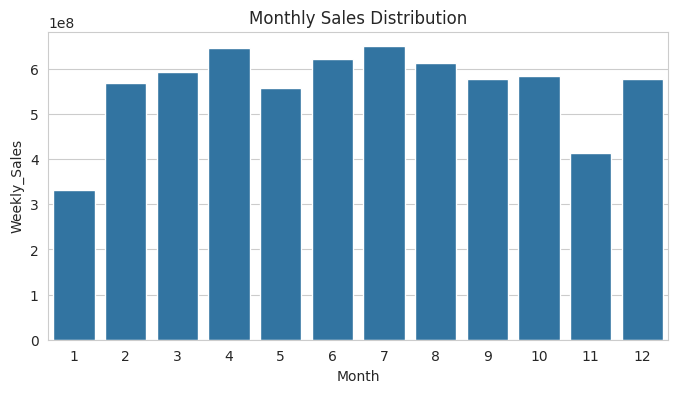

In [107]:
plt.figure(figsize=(8,4))
sns.barplot(x="Month", y="Weekly_Sales", data=monthly_sales)
plt.title("Monthly Sales Distribution")
plt.show()

Observation:


The monthly sales analysis shows that July records the highest total sales, followed by April and June. Contrary to the typical expectation that November and December dominate retail sales, this dataset shows stronger performance during the mid-year months, particularly during summer. January records the lowest sales, which may reflect the typical post-holiday reduction in consumer spending.

# Semester Sales Analysis

---



In [108]:
df["Semester"] = np.where(df["Month"] <= 6, 1, 2)

In [109]:
semester_sales = df.groupby("Semester")["Weekly_Sales"].sum().reset_index()

semester_sales

,Semester,Weekly_Sales
0,1,3.320727e+09
1,2,3.416492e+09


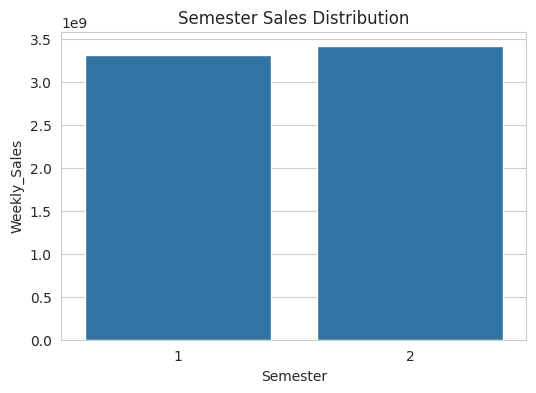

In [110]:
plt.figure(figsize=(6,4))
sns.barplot(x="Semester", y="Weekly_Sales", data=semester_sales)
plt.title("Semester Sales Distribution")
plt.show()

Observation:

The semester analysis shows that Semester 2 (July–December) generates higher total sales compared to Semester 1 (January–June). Total sales in the second semester are approximately $3.42 billion, compared with  $3.32 billion in the first semester. This suggests stronger retail demand in the latter half of the year, likely influenced by seasonal shopping events, back-to-school spending, and major holidays.

# Statistical Model

For Store 1 - Build prediction model to forecast demand

In [111]:
store1 = df[df["Store"] ==1]
store1.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Quarter,Semester,Day_Number
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2010,2,1,1,1
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,2010,2,1,1,8
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,2010,2,1,1,15
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,2010,2,1,1,22
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,2010,3,1,1,29


In [112]:
store1.shape

(143, 13)

In [113]:
x = store1[["Day_Number", "CPI", "Fuel_Price", "Unemployment"]]
y = store1["Weekly_Sales"]

In [114]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [115]:
from re import X
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [116]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [117]:
y_pred = model.predict(X_test)

In [118]:
r2 = r2_score(y_test, y_pred)
print("Model R2 score:", r2)

Model R2 score: 0.00979247176467779


In [119]:
coefficients = pd.DataFrame({
    "Feature": x.columns,
    "Coefficient": model.coef_
})

coefficients

,Feature,Coefficient
0,Day_Number,83.170747
1,CPI,14108.215546
2,Fuel_Price,-86633.915496
3,Unemployment,88317.366521


## Report
Prediction Model for Store 1

A linear regression model was developed to forecast weekly sales for Store 1 using economic indicators including CPI, fuel price, unemployment rate, and a time variable representing the day number since the beginning of the dataset. The model was trained using an 80/20 train-test split.

The resulting model produced an R² score of approximately 0.01, indicating that the selected variables explain less than 1% of the variance in weekly sales.

Fuel Prices (negative): Hihger Fuel prices --> customers spend less
(That makes economic sense)

CPI (positive): Higher CPI → higher sales.
Possible reason: Prices rise during inflation.

Unemployment (positive):This is counterintuitive. (There's not enough data so the model cannot reliably explain sales behavior)

This suggests that macroeconomic indicators such as CPI, unemployment rate, and fuel price have very limited predictive power for short-term retail sales at the store level.

The results imply that weekly sales are likely influenced more strongly by other factors such as seasonality, promotions, store-specific demand, and holiday effects, which are not included in this model.

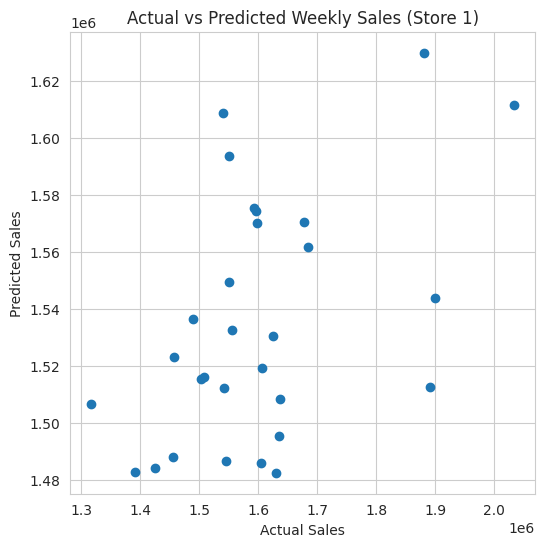

In [120]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Weekly Sales (Store 1)")
plt.show()

Observation:

As we can see the points scattered everywhere, confirming the weak model.

#Final Conclusion

This project explored Walmart retail sales data to identify patterns in store performance and evaluate factors that may influence demand. Through exploratory data analysis, several important insights were identified. Some stores generate significantly higher cumulative sales, while others exhibit higher variability in weekly performance. The analysis also showed that holiday weeks generally produce higher average sales compared to non-holiday periods, confirming the impact of seasonal events and promotions on retail demand.

Monthly and semester-level analysis revealed that overall sales tend to increase during the second half of the year, suggesting stronger consumer activity in later months. These results are consistent with typical retail trends influenced by seasonal shopping and holiday events.

A linear regression model was developed to forecast weekly sales for Store 1 using macroeconomic indicators such as CPI, fuel price, unemployment rate, and a time-based variable. The model produced a very low R² score (≈0.01), indicating that these economic indicators explain very little of the variation in weekly store sales. This suggests that short-term retail demand is likely driven more strongly by factors such as promotional events, holiday effects, local demand patterns, and store-specific characteristics rather than broader economic indicators.

Overall, this analysis demonstrates the importance of exploratory data analysis in understanding retail behavior and highlights the need for more complex models and additional variables to accurately predict store-level sales. Future improvements could include incorporating promotional markdown data, holiday-specific features, and advanced machine learning models.